In [ ]:
import sys
import os
import pathlib

# Adiciona o modulo de otimizacao ao sys.path
model_dir = pathlib.Path.cwd().parent / 'prosumer-stochastic-model'
if str(model_dir) not in sys.path:
    sys.path.append(str(model_dir))

from run_stochastic_model import main, exportar_todas_as_cargas_para_json
import matplotlib.pyplot as plt
import requests
import json

# Configuracao da otimizacao
config = dict()
config['has_storage'] = True
config['storage_rate'] = 0.2
config['storage_size'] = 10.0
config['max_energy_flow'] = config['storage_size'] * config['storage_rate']
config['max_soc'] = config['storage_size']
config['min_soc'] = 0.1 * config['storage_size']
config['bilateral_price'] = 38.0
config['bilateral_max'] = 5.0
config['node_id'] = 32
config['load_kw'] = 4.0
config['gen_kw'] = 1.0

# Executa a otimizacao
model = main(data=config)

# Exporta para JSON
caminho_saida = pathlib.Path.cwd().parent / 'data' / 'cargas_status.json'
json_path = exportar_todas_as_cargas_para_json(model, caminho=str(caminho_saida))

# Funcao para enviar corretamente
def enviar_json_para_raspberry(caminho_json, url='http://10.102.78.127:8000/atualizar_cargas'):
    try:
        with open(caminho_json, 'r', encoding='utf-8') as f:
            json_data = json.load(f)
        response = requests.post(
            url,
            json=json_data,
            headers={'Content-Type': 'application/json'}
        )
        print('📡 Requisicao enviada.')
        print('✅ Resposta do servidor:', response.status_code)
        print('📦 Conteudo:', response.text)
    except Exception as e:
        print('❌ Erro ao enviar JSON:', e)

# Envia para a Raspberry
enviar_json_para_raspberry(json_path)


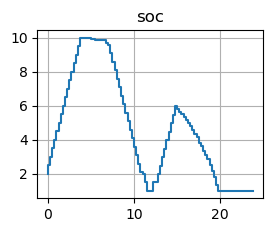

In [ ]:
soc_data = list(model.soc.get_values().values())
time_data = [t / 4 for t in range(len(soc_data))]
plt.subplot(2, 2, 1)
plt.step(time_data, soc_data)
plt.title('soc')
plt.grid(True)